# **Bloc science - Module 1**
**Silver Happy - Machine Learning et Analyse Data**


Importer le fichier silver_happy_dataset.csv à déposer dans le dossier "content" des fichiers en amont du lancement du programme

Ali JAHMI, 2i2

# **Mise en place de l'environnement**

Importation des librairies et du fichier nécessaires à l'analyse data.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GridSearchCV

df = pd.read_csv("/content/silver_happy_dataset.csv")

servicesCategories = ['Services à domicile', 'Cours & Formation', 'Santé & Bien-être', 'Loisirs & Sorties', 'Tourisme', 'Emploi Seniors', 'Shopping']

df.head()

,age,city,is_paris,months_since_inscription,language,dark_mode,font_accessibility,subscription_type,is_renewed,nb_interventions_total,...,nb_services_loisirs,nb_services_tourisme,nb_services_emploi,nb_services_cours,nb_orders_shop,avg_grade_given,total_spent,nb_quotes_requested,nb_quotes_accepted,next_service_type
0,75,Paris 13e,1,59,fr,0,1,annual_renewal,1,30,...,2,2,2,2,5,3.1,1728.43,10,1,Services à domicile
1,79,Rouen,0,47,fr,1,0,annual_renewal,1,7,...,0,0,0,7,2,3.3,971.01,1,0,Cours & Formation
2,86,Paris 11e,1,20,en,0,2,annual_standard,0,7,...,0,0,0,2,0,4.2,785.97,1,1,Services à domicile
3,71,Bordeaux,0,55,fr,0,0,annual_renewal,1,17,...,1,1,1,1,9,3.4,2663.60,3,1,Santé & Bien-être
4,82,Paris 18e,1,59,fr,1,1,annual_renewal,1,13,...,0,1,7,1,1,3.1,1676.87,3,2,Emploi Seniors


# **Calculs préalables**

Réalisation de calculs et application de formules basiques pour assurer une bonne vision globale du dataset

In [22]:
quoteConversionRate = (df['nb_quotes_accepted'] / df['nb_quotes_requested']).fillna(0)

lifeTimeValue = df['total_spent'] / df['months_since_inscription']

standardDeviation = []
for i in range(len(servicesCategories)):
  standardDeviation.append(df[df['next_service_type'] == servicesCategories[i]]['age'].std())

pearsonCoefficient, _ = pearsonr(df['avg_grade_given'], df['is_renewed'])

print(f"- Taux d'acceptation des devis : {quoteConversionRate.mean():.2f},\n\n- Profit généré par un adhérent tout au long de sa relation avec Silver Happy : {lifeTimeValue.mean():.2f},\n\n- Corrélation de Pearson entre les notes moyennes des prestations et le renouvellement de l'abonnement : {pearsonCoefficient:.3f}\n")

for i in range(len(standardDeviation)):
  print(f"- Écart type de l'âge (service analysé : {servicesCategories[i]}) : {standardDeviation[i]:.2f}")

- Taux d'acceptation des devis : 0.43,

- Profit généré par un adhérent tout au long de sa relation avec Silver Happy : 35.35,

- Corrélation de Pearson entre les notes moyennes des prestations et le renouvellement de l'abonnement : 0.019

- Écart type de l'âge (service analysé : Services à domicile) : 9.58
- Écart type de l'âge (service analysé : Cours & Formation) : 9.33
- Écart type de l'âge (service analysé : Santé & Bien-être) : 10.61
- Écart type de l'âge (service analysé : Loisirs & Sorties) : 7.54
- Écart type de l'âge (service analysé : Tourisme) : 5.65
- Écart type de l'âge (service analysé : Emploi Seniors) : 9.81
- Écart type de l'âge (service analysé : Shopping) : 7.02


# **Partie I : Génération d'un reporting permettant de suivre l'activité et d'améliorer la prise de décision**



# **Sous-partie 1 : Visualisation graphique des données**

Construction d'un total de 10 graphiques variés pour faciliter la visualisation et l'analyse des données relatives aux adhérents

In [23]:
sns.set_style("whitegrid", {
    "xtick.bottom": True,
    "ytick.left": True,
    "grid.linestyle": "--"
})

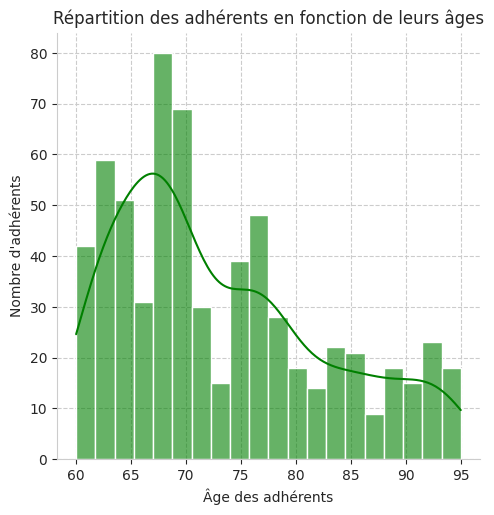

In [24]:
sns.displot( data=df["age"], kde=True, color="green", bins=20, alpha=0.6).set(
    xlabel="Âge des adhérents",
    ylabel="Nombre d'adhérents",
    title="Répartition des adhérents en fonction de leurs âges"
)

[Text(0.5, 0, "Nombre d'adhérents"),
 Text(0, 0.5, 'Ville'),
 Text(0.5, 1.0, 'Répartition géographique des adhérents en fonctions de leurs villes')]

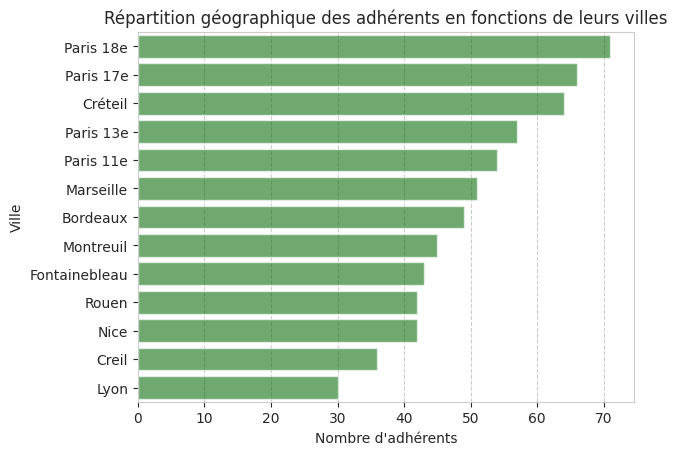

In [25]:
descendingCities = df['city'].value_counts().index

sns.countplot(data=df, y="city", color="green", alpha=0.6, order=descendingCities).set(
    xlabel="Nombre d'adhérents",
    ylabel="Ville",
    title="Répartition géographique des adhérents en fonctions de leurs villes"
)

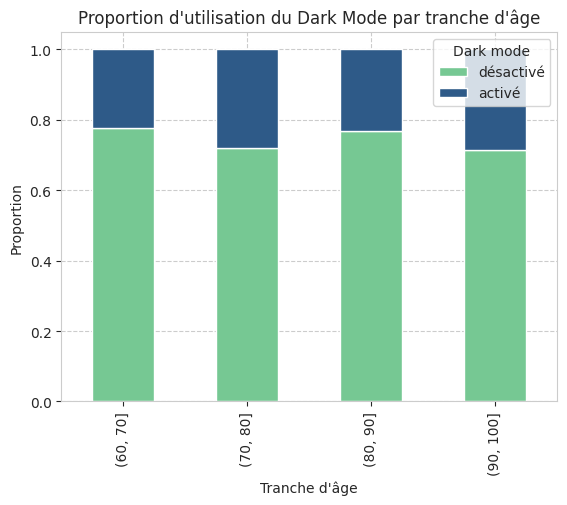

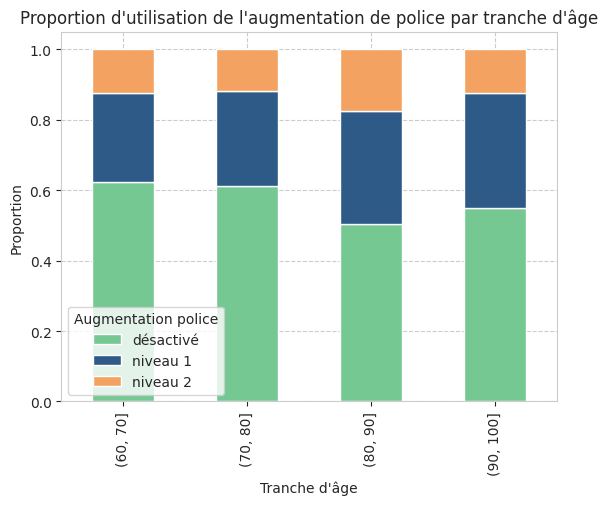

In [26]:
df['ageGroup'] = pd.cut(df['age'], bins=[60, 70, 80, 90, 100])

pd.crosstab(df['ageGroup'], df['dark_mode'], normalize='index').plot(kind='bar', stacked=True, color=['#76C893', '#2E5A88'])
plt.xlabel("Tranche d'âge")
plt.ylabel("Proportion")
plt.title("Proportion d'utilisation du Dark Mode par tranche d'âge")
plt.legend(['désactivé', 'activé'], title="Dark mode")
plt.show()

pd.crosstab(df['ageGroup'], df['font_accessibility'], normalize='index').plot(kind='bar', stacked=True, color=['#76C893', '#2E5A88', '#F4A261'])
plt.xlabel("Tranche d'âge")
plt.ylabel("Proportion")
plt.title("Proportion d'utilisation de l'augmentation de police par tranche d'âge")
plt.legend(['désactivé', 'niveau 1', 'niveau 2'], title="Augmentation police")
plt.show()

[Text(0.5, 0, "Nombre de mois depuis l'inscription"),
 Text(0, 0.5, 'Somme totale dépensée (en €)'),
 Text(0.5, 1.0, 'Somme totale dépensée en fonction du nombre de mois inscrit à Silver Happy')]

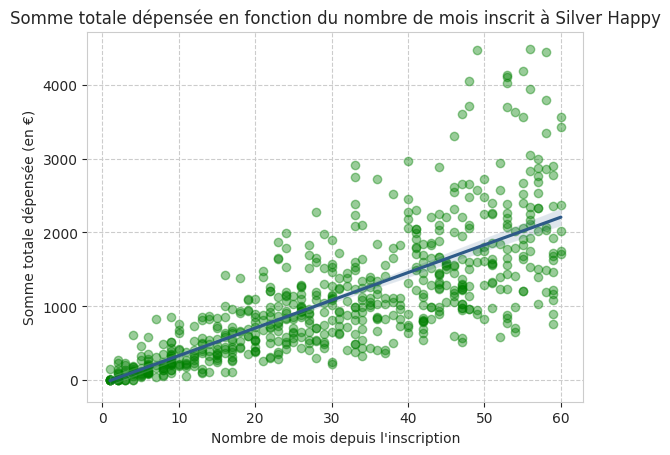

In [27]:
sns.regplot(x=df["months_since_inscription"], y=df["total_spent"], color="green", scatter_kws={'alpha':0.4}, line_kws={'color':'#2E5A88'}).set(
    xlabel="Nombre de mois depuis l'inscription",
    ylabel="Somme totale dépensée (en €)",
    title="Somme totale dépensée en fonction du nombre de mois inscrit à Silver Happy"
)

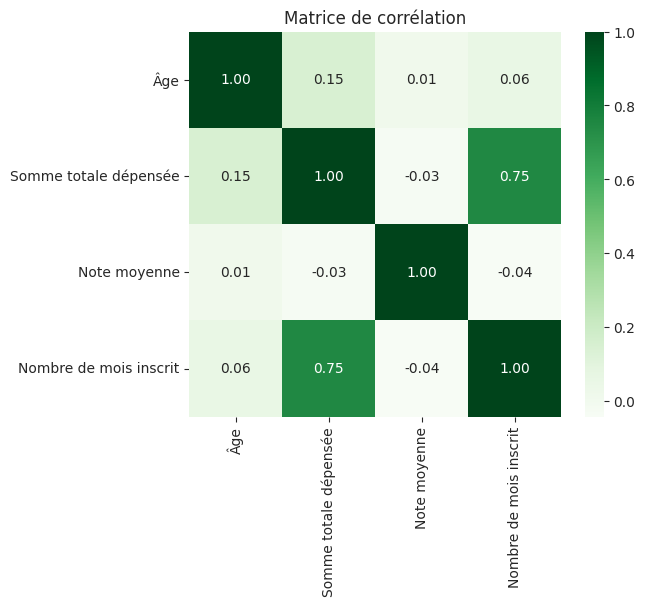

In [28]:
selectedColumns = ['age', 'total_spent', 'avg_grade_given', 'months_since_inscription']

matriceNames = ["Âge", "Somme totale dépensée", "Note moyenne", "Nombre de mois inscrit"]

correlationMatrice = df[selectedColumns].corr()
plt.figure(figsize=(6,5))
sns.heatmap(correlationMatrice, cmap="Greens", annot=True, fmt=".2f", xticklabels=matriceNames, yticklabels=matriceNames).set(
    title="Matrice de corrélation"
)
plt.show()

/tmp/ipykernel_38999/3768993610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="total_spent", y="next_service_type", palette="Greens")


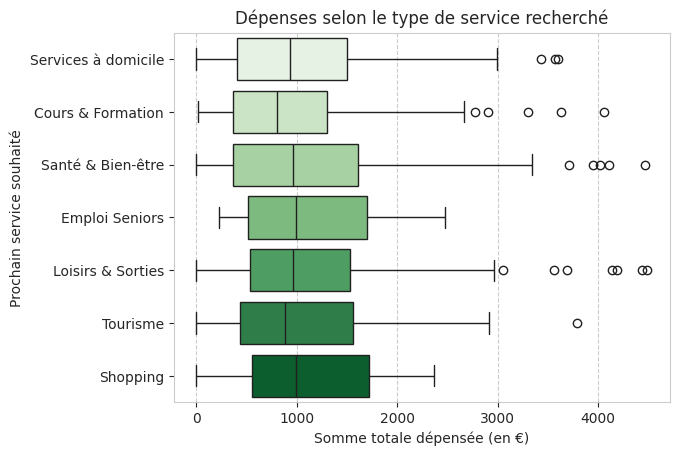

In [29]:
sns.boxplot(data=df, x="total_spent", y="next_service_type", palette="Greens")
plt.xlabel("Somme totale dépensée (en €)")
plt.ylabel("Prochain service souhaité")
plt.title("Dépenses selon le type de service recherché")
plt.show()

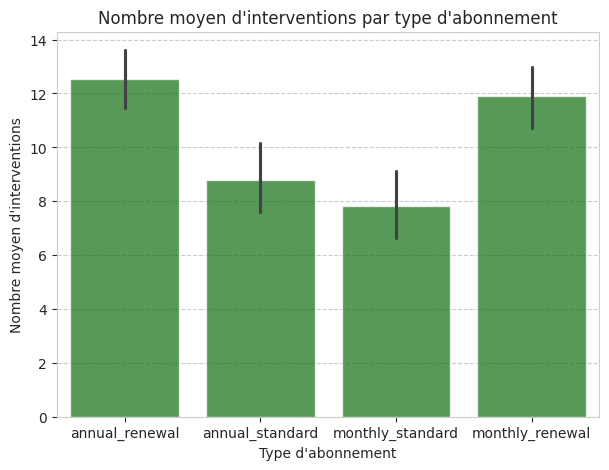

In [30]:
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="subscription_type", y="nb_interventions_total", color="green", alpha=0.7)
plt.xlabel("Type d'abonnement")
plt.ylabel("Nombre moyen d'interventions")
plt.title("Nombre moyen d'interventions par type d'abonnement")
plt.show()

# **Sous partie 2 : Dashboard**

Construction de deux dashboards statiques pour faciliter la visualisation et l'analyse des données relatives aux prestations et à leur succès

**Premier dashboard**

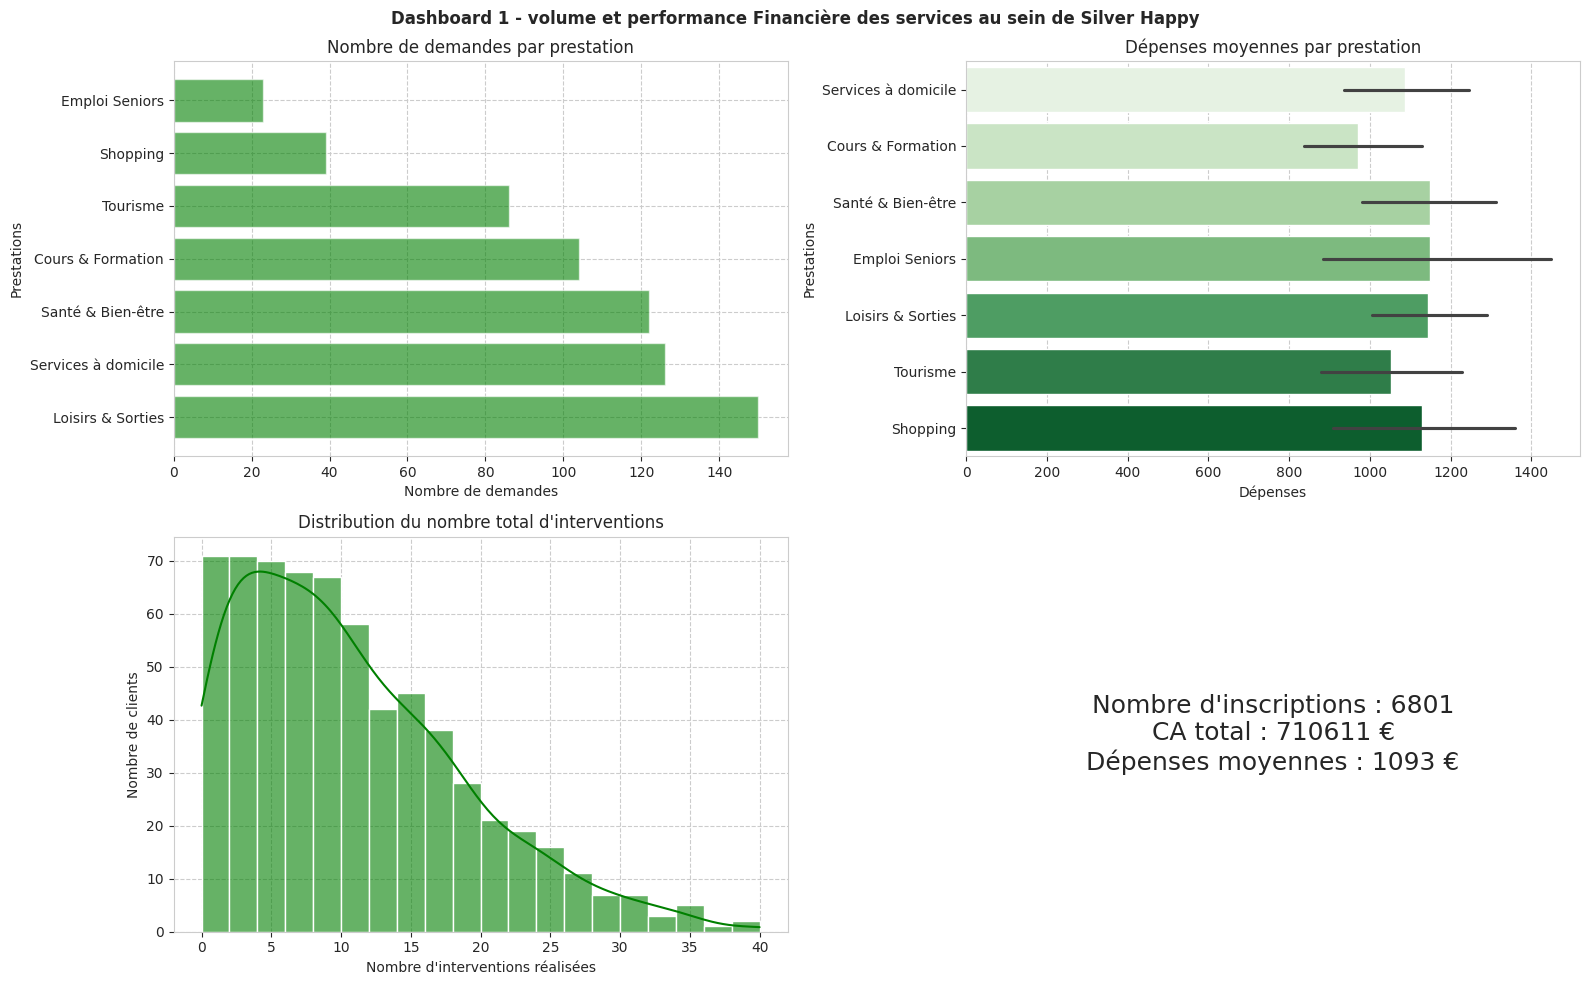

In [31]:
fig1, axes1 = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
fig1.suptitle('Dashboard 1 - volume et performance Financière des services au sein de Silver Happy', fontweight='bold')

vols = df['next_service_type'].value_counts()
axes1[0, 0].barh(vols.index, vols.values, color='green', alpha=0.6)
axes1[0, 0].set_title('Nombre de demandes par prestation')
axes1[0, 0].set_xlabel('Nombre de demandes')
axes1[0, 0].set_ylabel('Prestations')

sns.barplot(ax=axes1[0, 1], data=df, x='total_spent', y='next_service_type', hue='next_service_type', palette='Greens')
axes1[0, 1].set_title('Dépenses moyennes par prestation')
axes1[0, 1].set_xlabel('Dépenses')
axes1[0, 1].set_ylabel('Prestations')

sns.histplot(ax=axes1[1, 0], data=df, x='nb_interventions_total', kde=True, bins=20, color='green', alpha=0.6)
axes1[1, 0].set_title("Distribution du nombre total d'interventions")
axes1[1, 0].set_xlabel("Nombre d'interventions réalisées")
axes1[1, 0].set_ylabel("Nombre de clients")

axes1[1, 1].axis('off')
text = f"Nombre d'inscriptions : {df['nb_interventions_total'].sum()}\nCA total : {df['total_spent'].sum():.0f} €\nDépenses moyennes : {df['total_spent'].mean():.0f} €"
axes1[1, 1].text(0.5, 0.5, text, ha="center", va="center", fontsize=18)

plt.tight_layout()
plt.show()

**Second dashboard**

/tmp/ipykernel_38999/1923751752.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[1, 0].set_xticklabels(['Non renouvelé', 'Renouvelé'])


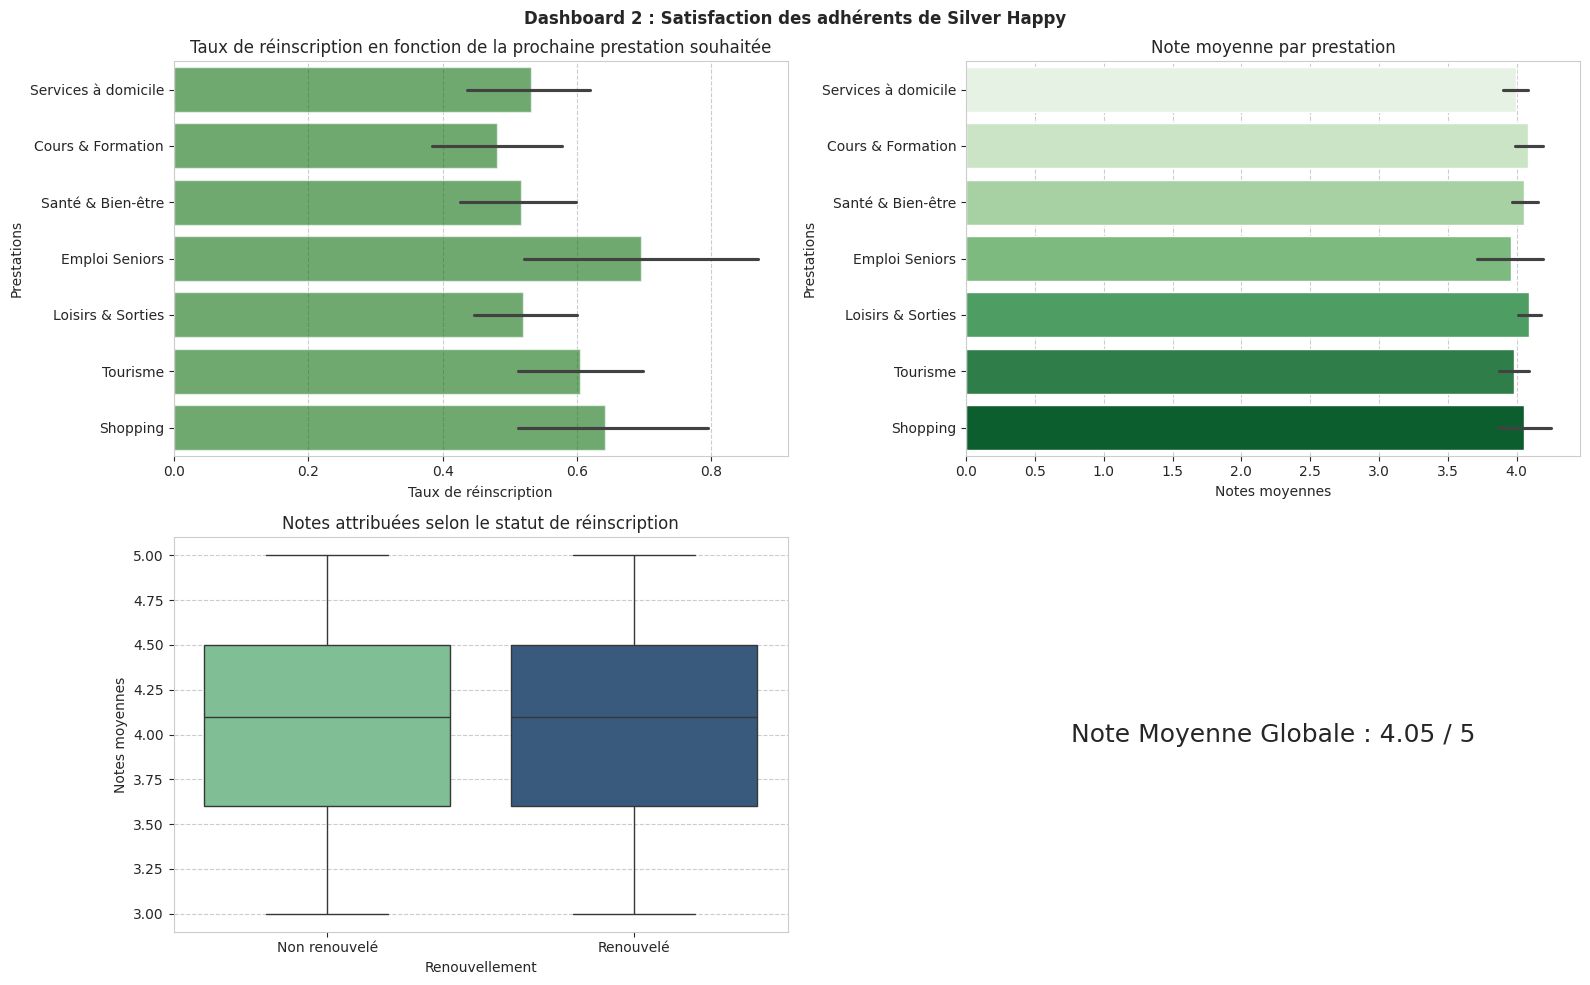

In [32]:
fig2, axes2 = plt.subplots(2, 2, figsize=(16, 10))
fig2.suptitle('Dashboard 2 : Satisfaction des adhérents de Silver Happy', fontweight='bold')

sns.barplot(ax=axes2[0, 0], data=df, x='is_renewed', y='next_service_type', color='green', alpha=0.6)
axes2[0, 0].set_title('Taux de réinscription en fonction de la prochaine prestation souhaitée')
axes2[0, 0].set_xlabel('Taux de réinscription')
axes2[0, 0].set_ylabel('Prestations')

sns.barplot(ax=axes2[0, 1], data=df, x='avg_grade_given', y='next_service_type', hue='next_service_type', palette='Greens')
axes2[0, 1].set_title('Note moyenne par prestation')
axes2[0, 1].set_xlabel('Notes moyennes')
axes2[0, 1].set_ylabel('Prestations')

sns.boxplot(ax=axes2[1, 0], data=df, x='is_renewed', y='avg_grade_given', hue='is_renewed', palette=['#76C893', '#2E5A88'], legend=False)
axes2[1, 0].set_title('Notes attribuées selon le statut de réinscription')
axes2[1, 0].set_xticklabels(['Non renouvelé', 'Renouvelé'])
axes2[1, 0].set_xlabel("Renouvellement")
axes2[1, 0].set_ylabel("Notes moyennes")

axes2[1, 1].axis('off')
text = f"Note Moyenne Globale : {df['avg_grade_given'].mean():.2f} / 5"
axes2[1, 1].text(0.5, 0.5, text, ha="center", va="center", fontsize=18)

plt.tight_layout()
plt.show()

# **Partie II : Machine Learning**

Implémentation d'un modèle de Machine Learning de classification permettant de prédire la prestation à laquelle un client est susceptible de souscrire

Data Preprocessing - Isolation de la cible, encodage des variables catégorielles et mise à l'échelle

In [33]:
df = pd.read_csv("/content/silver_happy_dataset.csv")

X = df.drop('next_service_type', axis=1)
Y = df['next_service_type']

X = pd.get_dummies(X, columns=['city', 'language', 'subscription_type'])

label_encoder = LabelEncoder()
Y = label_encoder.fit_transform(Y)

columnsNeedingStandarisation = ['age', 'total_spent', 'nb_interventions_total', 'nb_services_domicile', 'nb_services_medical', 'nb_services_online', 'nb_services_sante', 'nb_services_loisirs', 'nb_services_tourisme', 'nb_services_emploi', 'nb_services_cours', 'nb_orders_shop']
scaler = StandardScaler()
X[columnsNeedingStandarisation] = scaler.fit_transform(X[columnsNeedingStandarisation])

Séparation du jeu de données

In [34]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

Entraînement du modèle

In [35]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

Évaluation du modèle

- Exactitude : 0.83 (82.65%)

- Rapport de classification :

                     precision    recall  f1-score   support

  Cours & Formation       0.87      0.95      0.91        21
     Emploi Seniors       1.00      0.25      0.40         4
  Loisirs & Sorties       0.79      0.94      0.86        16
  Santé & Bien-être       0.93      0.93      0.93        28
Services à domicile       0.65      0.65      0.65        17
           Shopping       0.00      0.00      0.00         3
           Tourisme       1.00      0.89      0.94         9

           accuracy                           0.83        98
          macro avg       0.75      0.66      0.67        98
       weighted avg       0.83      0.83      0.82        98


- Matrice de confusion :



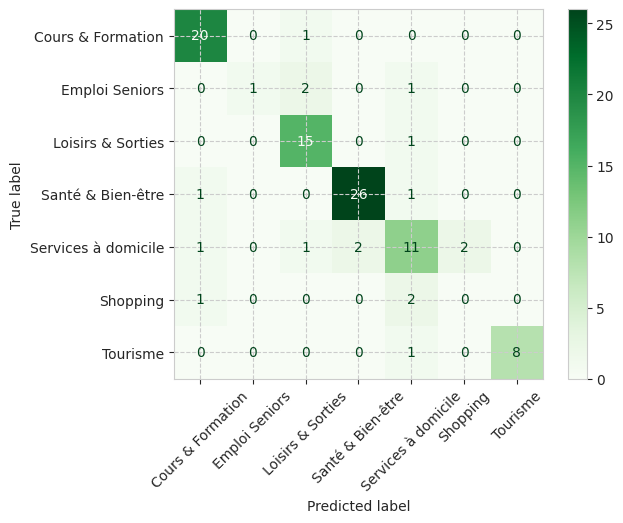

In [36]:
accuracy = accuracy_score(Y_test, Y_pred)

classificationReport = classification_report(Y_test, Y_pred, target_names=label_encoder.classes_)

cm = confusion_matrix(Y_test, Y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(xticks_rotation=45, cmap='Greens')

print(f"- Exactitude : {accuracy:.2f} ({accuracy*100:.2f}%)")
print("\n- Rapport de classification :\n")
print(classificationReport)
print("\n- Matrice de confusion :\n")

Optimisation du modèle

In [37]:
paramGrid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced', None]
}

grid = GridSearchCV(model, paramGrid, cv=5, scoring='f1_weighted')

grid.fit(X_train, Y_train)

bestModel = grid.best_estimator_

print(f"Les meilleurs paramètres sont : {grid.best_params_}")

Les meilleurs paramètres sont : {'class_weight': None, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


Test et évaluation du modèle optimisé

- Exactitude : 0.85 (84.69%)

- Rapport de classification :

                     precision    recall  f1-score   support

  Cours & Formation       0.91      0.95      0.93        21
     Emploi Seniors       1.00      0.25      0.40         4
  Loisirs & Sorties       0.79      0.94      0.86        16
  Santé & Bien-être       0.87      0.96      0.92        28
Services à domicile       0.79      0.65      0.71        17
           Shopping       0.00      0.00      0.00         3
           Tourisme       1.00      1.00      1.00         9

           accuracy                           0.85        98
          macro avg       0.77      0.68      0.69        98
       weighted avg       0.84      0.85      0.83        98


- Matrice de confusion :



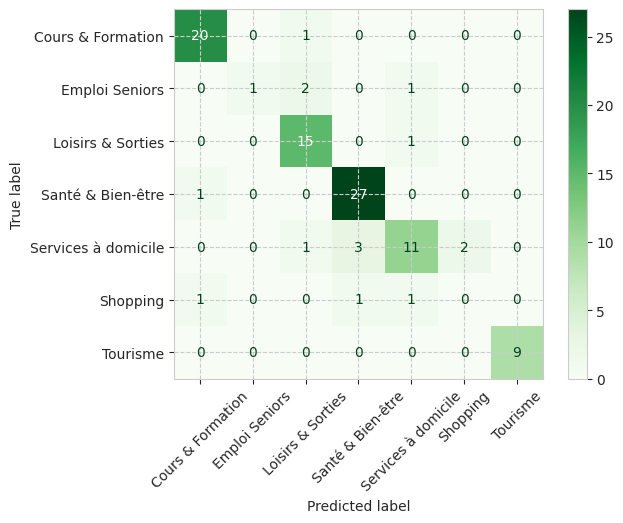

In [38]:
Y_pred_best = bestModel.predict(X_test)

accuracy = accuracy_score(Y_test, Y_pred_best)

classificationReport = classification_report(Y_test, Y_pred_best, target_names=label_encoder.classes_)

cm = confusion_matrix(Y_test, Y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_).plot(xticks_rotation=45, cmap='Greens')

print(f"- Exactitude : {accuracy:.2f} ({accuracy*100:.2f}%)")
print("\n- Rapport de classification :\n")
print(classificationReport)
print("\n- Matrice de confusion :\n")

Prédiction de la prochaine prestation à laquelle chaque client est susceptible de souscrire en conditions réelles

In [44]:
import datetime

df_to_predict = pd.read_csv("/content/silver_happy_dataset_to_predict.csv")

X_to_predict = df_to_predict.drop(columns=["next_service_type"])

X_to_predict = pd.get_dummies(X_to_predict, columns=['city', 'language', 'subscription_type'])

X_to_predict[columnsNeedingStandarisation] = scaler.transform(X_to_predict[columnsNeedingStandarisation])

X_to_predict = X_to_predict.reindex(columns=X.columns, fill_value=0)

predictions_encodees = bestModel.predict(X_to_predict)
df_to_predict["next_service_type"] = label_encoder.inverse_transform(predictions_encodees)

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

nom_fichier = f"silver_happy_dataset_predicted_{timestamp}.csv"

df_to_predict.to_csv(nom_fichier, index=False)